In [ ]:
#order if doing things: load data--> split data-->scale data-->build ANN -->Train-->Test


In [ ]:
#load the data
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data        # the measurements (features)
y = data.target       # the answers: 0 = malignant, 1 = benign

print("Number of samples:", X.shape[0])
print("Number of features per sample:", X.shape[1])
print("First sample's features:", X[0])
print("First sample's answer:", y[0])

Number of samples: 569
Number of features per sample: 30
First sample's features: [1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]
First sample's answer: 0


In [ ]:
#split into training and testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [ ]:
#scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train[0])


[-1.44075296 -0.43531947 -1.36208497 -1.1391179   0.78057331  0.71892128
  2.82313451 -0.11914956  1.09266219  2.45817261 -0.26380039 -0.01605246
 -0.47041357 -0.47476088  0.83836493  3.25102691  8.43893667  3.39198733
  2.62116574  2.06120787 -1.23286131 -0.47630949 -1.24792009 -0.97396758
  0.72289445  1.18673232  4.67282796  0.9320124   2.09724217  1.88645014]


In [ ]:
#build ann (the brain)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
#train the model
history = model.fit(X_train, y_train,
                     validation_split=0.2,
                     epochs=50,
                     batch_size=16,
                     verbose=1)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3901 - loss: 0.7561 - val_accuracy: 0.4505 - val_loss: 0.6470
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7253 - loss: 0.5675 - val_accuracy: 0.8681 - val_loss: 0.5182
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8571 - loss: 0.4753 - val_accuracy: 0.9011 - val_loss: 0.4452
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8874 - loss: 0.4086 - val_accuracy: 0.9451 - val_loss: 0.3802
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9093 - loss: 0.3485 - val_accuracy: 0.9451 - val_loss: 0.3231
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9203 - loss: 0.2969 - val_accuracy: 0.9451 - val_loss: 0.2751
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9286 - loss: 0.2536 - val_accuracy: 0.9451 - val_loss: 0.2367
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9451 - loss: 0.2182 - val_accuracy: 0.9560 - val_loss

In [ ]:
#evaluate on the test set
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9649 - loss: 0.0769
Test Accuracy: 0.9649122953414917


In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Confusion Matrix:
[[41  2]
 [ 2 69]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



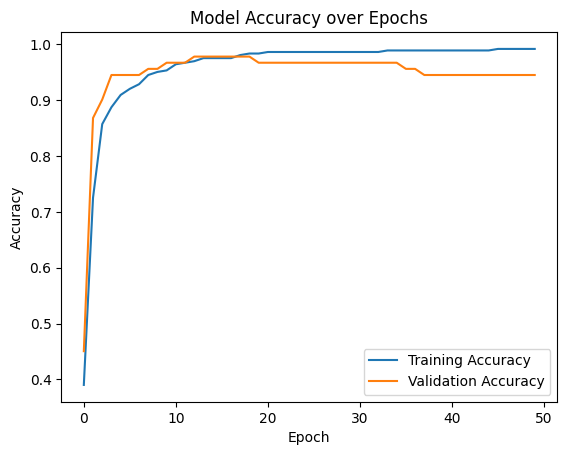

In [ ]:
#plot accuracy over training
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy over Epochs')
plt.legend()
plt.show()

In [ ]:
# Save the trained model
model.save('breast_cancer_ann.keras')

# Save the scaler too (needed to preprocess new inputs later)
import joblib
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved!")

NameError: name 'model' is not defined